In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# =====================================
# 1. Load data: news and metadata
# =====================================
import pandas as pd

# If files are in the Colab working directory:
df_news = pd.read_csv("/content/drive/MyDrive/MNA/Fintech e innovación digital en finanzas /df_news.csv")
df_meta = pd.read_csv("/content/drive/MyDrive/MNA/Fintech e innovación digital en finanzas /df_metadata-1.csv")

print("df_news shape:", df_news.shape)
print("df_meta shape:", df_meta.shape)

df_news.head(), df_meta.head()


df_news shape: (4871, 6)
df_meta shape: (490, 4)


(  TICKER                                              TITLE  \
 0    MMM  2 Dow Jones Stocks with Promising Prospects an...   
 1    MMM               3 S&P 500 Stocks Skating on Thin Ice   
 2    MMM  3M Rises 15.8% YTD: Should You Buy the Stock N...   
 3    MMM  Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...   
 4    MMM  3 Cash-Producing Stocks with Questionable Fund...   
 
                                              SUMMARY  \
 0  The Dow Jones (^DJI) is made up of 30 of the m...   
 1  The S&P 500 (^GSPC) is often seen as a benchma...   
 2  MMM is making strides in the aerospace, indust...   
 3  Quarterly earnings results are a good time to ...   
 4  While strong cash flow is a key indicator of s...   
 
             PUBLICATION_DATE    PROVIDER  \
 0  2025-05-29 04:33:58+00:00  StockStory   
 1  2025-05-27 04:34:42+00:00  StockStory   
 2  2025-05-22 14:08:00+00:00       Zacks   
 3  2025-05-22 03:31:21+00:00  StockStory   
 4  2025-05-19 04:41:32+00:00  StockStory   


In [5]:
# =====================================
# 2. Basic cleaning and preprocessing
# =====================================

# Drop duplicate summaries to avoid repeated news
df_news = df_news.drop_duplicates("SUMMARY").reset_index(drop=True)

# Convert publication date to date (no time)
df_news["PUBLICATION_DATE"] = pd.to_datetime(df_news["PUBLICATION_DATE"]).dt.date

# Keep only rows where ticker exists in metadata (consistency step)
valid_tickers = set(df_meta["TICKER"])
df_news = df_news[df_news["TICKER"].isin(valid_tickers)].reset_index(drop=True)

print("After cleaning, df_news shape:", df_news.shape)
df_news.head()


After cleaning, df_news shape: (3976, 6)


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...


In [6]:
# =====================================
# 3. NLI model and sentiment scoring
# =====================================
from sentence_transformers import CrossEncoder
import numpy as np

# Load the NLI cross-encoder model
# This will download weights the first time.
model = CrossEncoder("cross-encoder/nli-deberta-v3-base")

positive_hypothesis = "This text is positive."
negative_hypothesis = "This text is negative."

titles = df_news["TITLE"].astype(str).tolist()

# Create premise-hypothesis pairs
positive_pairs = [(t, positive_hypothesis) for t in titles]
negative_pairs = [(t, negative_hypothesis) for t in titles]

len(positive_pairs), len(negative_pairs)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

(3976, 3976)

In [7]:
# =====================================
# 3.1 Batched prediction for memory safety
# =====================================

def batched_predict(pairs, batch_size=64):
    """
    Helper function to run model predictions in batches.
    Returns an array of shape (n_samples, num_labels).
    """
    all_probs = []
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i : i + batch_size]
        probs = model.predict(batch, apply_softmax=True)
        all_probs.append(probs)
    return np.vstack(all_probs)

# Predict entailment probabilities for positive and negative hypotheses
positive_probs = batched_predict(positive_pairs, batch_size=64)
negative_probs = batched_predict(negative_pairs, batch_size=64)

# Column 1 corresponds to "entailment" in this NLI model's label space
positive_entail = positive_probs[:, 1]
negative_entail = negative_probs[:, 1]

# Sentiment score: P(positive entailment) - P(negative entailment)
df_news["Sentiment"] = positive_entail - negative_entail

df_news[["TITLE", "Sentiment"]].head()


,TITLE,Sentiment
0,2 Dow Jones Stocks with Promising Prospects an...,0.971007
1,3 S&P 500 Stocks Skating on Thin Ice,0.009601
2,3M Rises 15.8% YTD: Should You Buy the Stock N...,0.002030
3,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,0.000080
4,3 Cash-Producing Stocks with Questionable Fund...,-0.003393


In [8]:
# =====================================
# 4. Daily sentiment time series
# =====================================

df_daily_sentiment = (
    df_news.groupby("PUBLICATION_DATE")["Sentiment"]
           .mean()
           .to_frame("daily_sentiment")
)

df_daily_sentiment.index = pd.to_datetime(df_daily_sentiment.index)
df_daily_sentiment.sort_index(inplace=True)

print("Daily sentiment shape:", df_daily_sentiment.shape)
df_daily_sentiment.head()


Daily sentiment shape: (118, 1)


,daily_sentiment
PUBLICATION_DATE,
2024-07-12,-0.000194
2024-07-22,0.006325
2024-08-19,0.009501
2024-09-13,-0.000013
2024-10-26,0.986952


In [9]:
# =====================================
# 5. Market data: prices and returns
# =====================================
import yfinance as yf

# Extract unique tickers from news
tickers = sorted(df_news["TICKER"].unique().tolist())

start_date = df_daily_sentiment.index.min()
end_date = df_daily_sentiment.index.max()

print("Downloading prices from", start_date.date(), "to", end_date.date())
print("Number of tickers:", len(tickers))

# Download adjusted close prices
price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False
)["Close"]

price_data.head()


Number of tickers: 487


[**                     4%                       ]  18 of 487 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
[*********             18%                       ]  90 of 487 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
[*********************100%***********************]  487 of 487 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['PARA', 'ANSS', 'JNPR', 'WBA']: YFTzMissingError('possibly delisted; no timezone found')


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WST,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-12,132.229996,230.539993,170.279999,146.779999,104.220001,96.500000,310.630005,559.049988,238.559998,64.279999,...,322.980011,264.209991,29.280001,85.830002,54.279999,113.269997,138.419998,131.309998,108.690002,179.039993
2024-07-15,131.009995,234.399994,168.029999,147.220001,102.959999,97.160004,317.869995,565.710022,237.720001,63.400002,...,320.109985,263.329987,29.040001,84.599998,53.230000,115.209999,137.300003,127.889999,106.529999,177.979996
2024-07-16,136.059998,234.820007,169.199997,151.259995,102.720001,97.110001,325.000000,566.539978,243.330002,64.559998,...,329.109985,264.320007,29.730000,85.949997,53.930000,116.040001,141.259995,128.919998,107.459999,182.910004
2024-07-17,133.500000,228.880005,175.270004,148.000000,104.680000,97.870003,325.600006,563.090027,235.610001,65.720001,...,327.040009,267.470001,30.490000,84.919998,55.320000,117.639999,139.000000,129.330002,111.050003,182.050003
2024-07-18,131.970001,224.179993,171.139999,146.880005,100.070000,98.239998,328.100006,556.849976,238.990005,64.790001,...,316.339996,266.640015,30.309999,83.480003,55.779999,118.800003,138.039993,128.309998,111.389999,179.229996


In [10]:
# =====================================
# 5.1 Equal-weighted index and daily returns
# =====================================

# Drop columns with all NaNs (just in case)
price_data = price_data.dropna(axis=1, how="all")

# Equal-weighted index: average across available tickers each day
eq_index = price_data.mean(axis=1)

# Daily returns of the equal-weighted index
daily_returns = eq_index.pct_change().rename("daily_return").to_frame()
daily_returns.head()


,daily_return
Date,
2024-07-12,NaN
2024-07-15,0.003108
2024-07-16,0.019326
2024-07-17,-0.011730
2024-07-18,-0.008559


In [11]:
# =====================================
# 6. Merge sentiment and returns
# =====================================

df_merged = df_daily_sentiment.join(daily_returns, how="inner")

print("Merged shape:", df_merged.shape)
df_merged.head()


Merged shape: (83, 2)


,daily_sentiment,daily_return
2024-07-12,-0.000194,NaN
2024-07-22,0.006325,0.011173
2024-08-19,0.009501,0.007810
2024-09-13,-0.000013,0.008915
2024-11-12,0.979375,-0.007242


In [12]:
# =====================================
# 6.1 Correlation and descriptive statistics
# =====================================

corr_sr = df_merged["daily_sentiment"].corr(df_merged["daily_return"])
print("Correlation (daily_sentiment, daily_return):", corr_sr)

df_merged.describe()


Correlation (daily_sentiment, daily_return): -0.09167315977630396


,daily_sentiment,daily_return
count,83.000000,82.000000
mean,0.190603,0.001154
std,0.427920,0.014603
min,-0.994133,-0.041624
25%,-0.000068,-0.006270
50%,0.159287,0.000654
75%,0.335999,0.009096
max,0.992132,0.079046


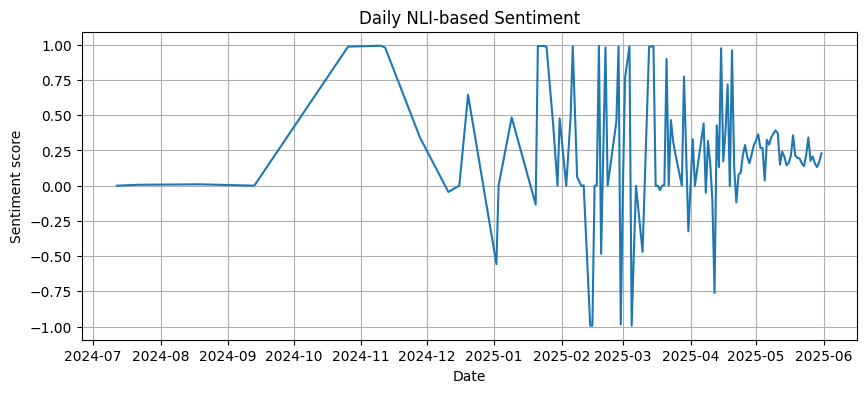

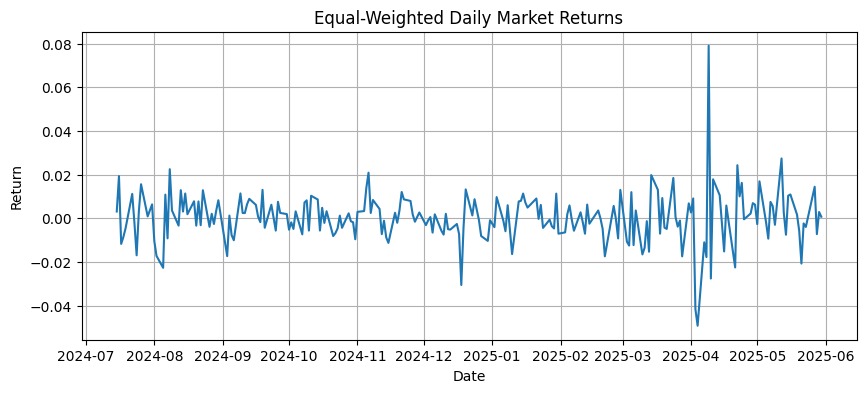

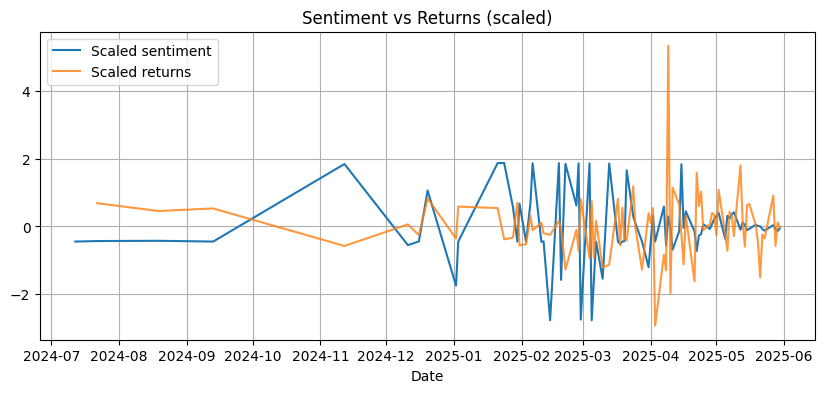

In [13]:
# =====================================
# 7. Basic plots
# =====================================
import matplotlib.pyplot as plt

# 7.1 Daily sentiment
plt.figure(figsize=(10, 4))
plt.plot(df_daily_sentiment.index, df_daily_sentiment["daily_sentiment"])
plt.title("Daily NLI-based Sentiment")
plt.xlabel("Date")
plt.ylabel("Sentiment score")
plt.grid(True)
plt.show()

# 7.2 Daily returns
plt.figure(figsize=(10, 4))
plt.plot(daily_returns.index, daily_returns["daily_return"])
plt.title("Equal-Weighted Daily Market Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

# 7.3 Overlay sentiment vs returns (scaled)
plt.figure(figsize=(10, 4))
# Simple scaling to make them comparable on the same axis
sent_scaled = (df_merged["daily_sentiment"] - df_merged["daily_sentiment"].mean()) / df_merged["daily_sentiment"].std()
ret_scaled   = (df_merged["daily_return"]   - df_merged["daily_return"].mean())   / df_merged["daily_return"].std()

plt.plot(df_merged.index, sent_scaled, label="Scaled sentiment")
plt.plot(df_merged.index, ret_scaled, label="Scaled returns", alpha=0.8)
plt.title("Sentiment vs Returns (scaled)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
# =====================================
# 8. Econometric model: OLS regression
# =====================================
import statsmodels.api as sm

# Drop any remaining NaNs
reg_data = df_merged.dropna(subset=["daily_sentiment", "daily_return"])

X = reg_data["daily_sentiment"]
y = reg_data["daily_return"]

X = sm.add_constant(X)  # adds intercept
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           daily_return   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.6780
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.413
Time:                        22:27:08   Log-Likelihood:                 231.07
No. Observations:                  82   AIC:                            -458.1
Df Residuals:                      80   BIC:                            -453.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0018      0.002     

In [15]:
# =====================================
# 8.1 Predictive regression: return_{t+1} on sentiment_t
# =====================================

df_pred = df_merged.copy()
df_pred["return_lead"] = df_pred["daily_return"].shift(-1)

reg_pred = df_pred.dropna(subset=["daily_sentiment", "return_lead"])

X_pred = reg_pred["daily_sentiment"]
y_pred = reg_pred["return_lead"]

X_pred = sm.add_constant(X_pred)
model_pred = sm.OLS(y_pred, X_pred).fit()

print(model_pred.summary())


                            OLS Regression Results                            
Dep. Variable:            return_lead   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                   0.08859
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.767
Time:                        22:27:08   Log-Likelihood:                 230.77
No. Observations:                  82   AIC:                            -457.5
Df Residuals:                      80   BIC:                            -452.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0009      0.002     

In [16]:
# =====================================
# 9. Sector-level sentiment and returns (optional)
# =====================================

# Merge sentiment with metadata to get sector per ticker
news_with_sector = df_news.merge(df_meta[["TICKER", "SECTOR"]], on="TICKER", how="left")

news_with_sector["PUBLICATION_DATE"] = pd.to_datetime(news_with_sector["PUBLICATION_DATE"])

# Monthly sector sentiment
monthly_sector_sentiment = (
    news_with_sector
    .groupby([pd.Grouper(key="PUBLICATION_DATE", freq="M"), "SECTOR"])["Sentiment"]
    .mean()
    .reset_index()
    .rename(columns={"Sentiment": "monthly_sentiment"})
)

monthly_sector_sentiment.head()


/tmp/ipython-input-2200941162.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(key="PUBLICATION_DATE", freq="M"), "SECTOR"])["Sentiment"]


,PUBLICATION_DATE,SECTOR,monthly_sentiment
0,2024-07-31,Real Estate,0.003066
1,2024-08-31,Real Estate,0.009501
2,2024-09-30,Real Estate,-0.000013
3,2024-10-31,Real Estate,0.986952
4,2024-11-30,Financial Services,0.340241


In [17]:
############## CÓDIGO ACCESORIO, NO FORMA PARTE DEL TRABAJO FINAL ##############

# ==========================================
# 1. Revisar qué sectores existen en df_meta
# ==========================================
print("SECTORES EN df_meta:")
print(df_meta['SECTOR'].value_counts(), "\n")

# ===================================================
# 2. Revisar si el merge está asignando sectores bien
# ===================================================
merged = df_news.merge(df_meta[['TICKER', 'SECTOR']],
                       on='TICKER', how='left')

print("SECTORES LUEGO DEL MERGE (incluyendo NaN):")
print(merged['SECTOR'].value_counts(dropna=False), "\n")

# =======================================================
# 3. Cuántas filas no encontraron sector (deben ser pocas)
# =======================================================
sin_sector = merged['SECTOR'].isna().sum()
print(f"Filas sin sector asignado: {sin_sector} de {len(merged)}", "\n")

# =======================================================
# 4. Revisar cuántos tickers de df_news están en df_meta
# =======================================================
tickers_news = set(df_news['TICKER'])
tickers_meta = set(df_meta['TICKER'])

interseccion = tickers_news & tickers_meta

print(f"Tickers en df_news: {len(tickers_news)}")
print(f"Tickers en df_meta: {len(tickers_meta)}")
print(f"Tickers que hacen match: {len(interseccion)}")
print(f"Tickers sin match: {len(tickers_news - tickers_meta)}", "\n")

# =======================================================
# 5. Revisar cuántos sectores aparecen en la tabla mensual
# =======================================================

# Asegurar formato de fecha
merged["PUBLICATION_DATE"] = pd.to_datetime(merged["PUBLICATION_DATE"], errors='coerce')

monthly_sector_sentiment = (
    merged
    .groupby([pd.Grouper(key="PUBLICATION_DATE", freq="M"), "SECTOR"])["Sentiment"]
    .mean()
    .reset_index()
    .rename(columns={"Sentiment": "monthly_sentiment"})
)

print("SECTORES PRESENTES EN monthly_sector_sentiment:")
print(monthly_sector_sentiment['SECTOR'].value_counts(), "\n")

# =======================================================
# 6. Ver un ejemplo más amplio que .head()
# =======================================================
print("PRIMERAS 20 FILAS DE monthly_sector_sentiment:")
print(monthly_sector_sentiment.head(20))


SECTORES EN df_meta:
SECTOR
Technology                81
Industrials               70
Financial Services        66
Healthcare                58
Consumer Cyclical         55
Consumer Defensive        36
Real Estate               31
Utilities                 30
Communication Services    23
Energy                    21
Basic Materials           19
Name: count, dtype: int64 

SECTORES LUEGO DEL MERGE (incluyendo NaN):
SECTOR
Technology                664
Financial Services        581
Industrials               567
Healthcare                458
Consumer Cyclical         434
Consumer Defensive        281
Real Estate               264
Utilities                 239
Energy                    185
Basic Materials           153
Communication Services    150
Name: count, dtype: int64 

Filas sin sector asignado: 0 de 3976 

Tickers en df_news: 487
Tickers en df_meta: 490
Tickers que hacen match: 487
Tickers sin match: 0 

SECTORES PRESENTES EN monthly_sector_sentiment:
SECTOR
Real Estate            

/tmp/ipython-input-235434392.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(key="PUBLICATION_DATE", freq="M"), "SECTOR"])["Sentiment"]


In [18]:
df_news["PUBLICATION_DATE"].min(), df_news["PUBLICATION_DATE"].max()


(datetime.date(2024, 7, 12), datetime.date(2025, 5, 31))